In [ ]:
# ═══════════════════════════════════════════════════
# CELL 1 — Setup (Exploration / Raw Data)
# ═══════════════════════════════════════════════════
import sys
import os
import warnings

# Allow imports from project root (src/)
sys.path.append('..')

# Set CWD to project root
os.chdir("..")
print("CWD:", os.getcwd())

# Common libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path    # ← THIS was missing

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

print("✅ Setup complete (Exploration)")

CWD: /Users/apple/NetSentinel
✅ Setup complete (Exploration)


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 2 — Load All CSV Files
# ═══════════════════════════════════════════════════
data_path = Path("data/raw/")
csv_files = list(data_path.glob("*.csv"))

print(f"Found {len(csv_files)} files:")
for f in csv_files:
    print(f"  → {f.name}")

NameError: name 'Path' is not defined

In [ ]:
# ═══════════════════════════════════════════════════
# CELL 3 — Merge All Files Into One DataFrame
# ═══════════════════════════════════════════════════
dfs = []
for f in csv_files:
    print(f"Loading {f.name}...")
    temp = pd.read_csv(f, low_memory=False)
    temp.columns = temp.columns.str.strip()  # Clean column names
    dfs.append(temp)
    print(f"  → {temp.shape[0]:,} rows, {temp.shape[1]} columns")

df = pd.concat(dfs, ignore_index=True)
print(f"\n✅ Total: {df.shape[0]:,} rows, {df.shape[1]} columns")

Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
  → 288,602 rows, 79 columns
Loading Monday-WorkingHours.pcap_ISCX.csv...
  → 529,918 rows, 79 columns
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
  → 191,033 rows, 79 columns
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
  → 286,467 rows, 79 columns
Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
  → 225,745 rows, 79 columns
Loading Tuesday-WorkingHours.pcap_ISCX.csv...
  → 445,909 rows, 79 columns
Loading Wednesday-workingHours.pcap_ISCX.csv...
  → 692,703 rows, 79 columns
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
  → 170,366 rows, 79 columns

✅ Total: 2,830,743 rows, 79 columns


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 4 — Inspect the Data
# ═══════════════════════════════════════════════════
print("=" * 60)
print("COLUMNS:")
print("=" * 60)
for i, col in enumerate(df.columns):
    print(f"  {i:3d}. {col}")

print(f"\n{'=' * 60}")
print("FIRST 5 ROWS:")
print("=" * 60)
df.head()

COLUMNS:
    0. Destination Port
    1. Flow Duration
    2. Total Fwd Packets
    3. Total Backward Packets
    4. Total Length of Fwd Packets
    5. Total Length of Bwd Packets
    6. Fwd Packet Length Max
    7. Fwd Packet Length Min
    8. Fwd Packet Length Mean
    9. Fwd Packet Length Std
   10. Bwd Packet Length Max
   11. Bwd Packet Length Min
   12. Bwd Packet Length Mean
   13. Bwd Packet Length Std
   14. Flow Bytes/s
   15. Flow Packets/s
   16. Flow IAT Mean
   17. Flow IAT Std
   18. Flow IAT Max
   19. Flow IAT Min
   20. Fwd IAT Total
   21. Fwd IAT Mean
   22. Fwd IAT Std
   23. Fwd IAT Max
   24. Fwd IAT Min
   25. Bwd IAT Total
   26. Bwd IAT Mean
   27. Bwd IAT Std
   28. Bwd IAT Max
   29. Bwd IAT Min
   30. Fwd PSH Flags
   31. Bwd PSH Flags
   32. Fwd URG Flags
   33. Bwd URG Flags
   34. Fwd Header Length
   35. Bwd Header Length
   36. Fwd Packets/s
   37. Bwd Packets/s
   38. Min Packet Length
   39. Max Packet Length
   40. Packet Length Mean
   41. Packet Le

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,166,1,1,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.000000,12048.192770,166.0000,0.000000e+00,166,166,0,0.0000,0.000,0,0,0,0.0,0.0,0,0,0,0,0,0,32,32,6024.096386,6024.096386,0,0,0.0,0.0,0.0,0,0,0,0,1,1,0,0,1,0.0,0.0,0.0,32,0,0,0,0,0,0,1,0,1,0,290,243,0,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
1,60148,83,1,2,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.000000,36144.578310,41.5000,1.060660e+01,49,34,0,0.0000,0.000,0,0,49,49.0,0.0,49,49,0,0,0,0,32,64,12048.192770,24096.385540,0,0,0.0,0.0,0.0,0,0,0,0,1,1,0,0,2,0.0,0.0,0.0,32,0,0,0,0,0,0,1,0,2,0,243,290,0,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2,123,99947,1,1,48,48,48,48,48.0,0.0,48,48,48.0,0.0,960.509070,20.010606,99947.0000,0.000000e+00,99947,99947,0,0.0000,0.000,0,0,0,0.0,0.0,0,0,0,0,0,0,40,40,10.005303,10.005303,48,48,48.0,0.0,0.0,0,0,0,0,0,0,0,0,1,72.0,48.0,48.0,40,0,0,0,0,0,0,1,48,1,48,-1,-1,0,40,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
3,123,37017,1,1,48,48,48,48,48.0,0.0,48,48,48.0,0.0,2593.403031,54.029230,37017.0000,0.000000e+00,37017,37017,0,0.0000,0.000,0,0,0,0.0,0.0,0,0,0,0,0,0,32,32,27.014615,27.014615,48,48,48.0,0.0,0.0,0,0,0,0,0,0,0,0,1,72.0,48.0,48.0,32,0,0,0,0,0,0,1,48,1,48,-1,-1,0,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
4,0,111161336,147,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.000000,1.322402,761379.0137,2.539814e+06,13600000,0,111000000,761379.0137,2539814.273,13600000,0,0,0.0,0.0,0,0,0,0,0,0,0,0,1.322402,0.000000,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,0,147,0,0,0,-1,-1,0,0,1753752.625,2123197.578,4822992,95,9463032.7,2657727.996,13600000,5700287,BENIGN


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 5 — Label Distribution
# ═══════════════════════════════════════════════════
print("=" * 60)
print("LABEL DISTRIBUTION:")
print("=" * 60)

label_counts = df['Label'].value_counts()
print(label_counts)
print(f"\nTotal samples: {len(df):,}")
print(f"Benign: {label_counts.get('BENIGN', 0):,} ({label_counts.get('BENIGN', 0)/len(df)*100:.1f}%)")
print(f"Attack: {len(df) - label_counts.get('BENIGN', 0):,} ({(len(df) - label_counts.get('BENIGN', 0))/len(df)*100:.1f}%)")

LABEL DISTRIBUTION:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Total samples: 2,830,743
Benign: 2,273,097 (80.3%)
Attack: 557,646 (19.7%)


/var/folders/10/471w2rks2_g1vsz0bq3bm2_00000gn/T/ipykernel_75384/3760746121.py:21: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/10/471w2rks2_g1vsz0bq3bm2_00000gn/T/ipykernel_75384/3760746121.py:22: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.savefig("../notebooks/label_distribution.png", dpi=150, bbox_inches='tight')
/Users/apple/NetSentinel/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


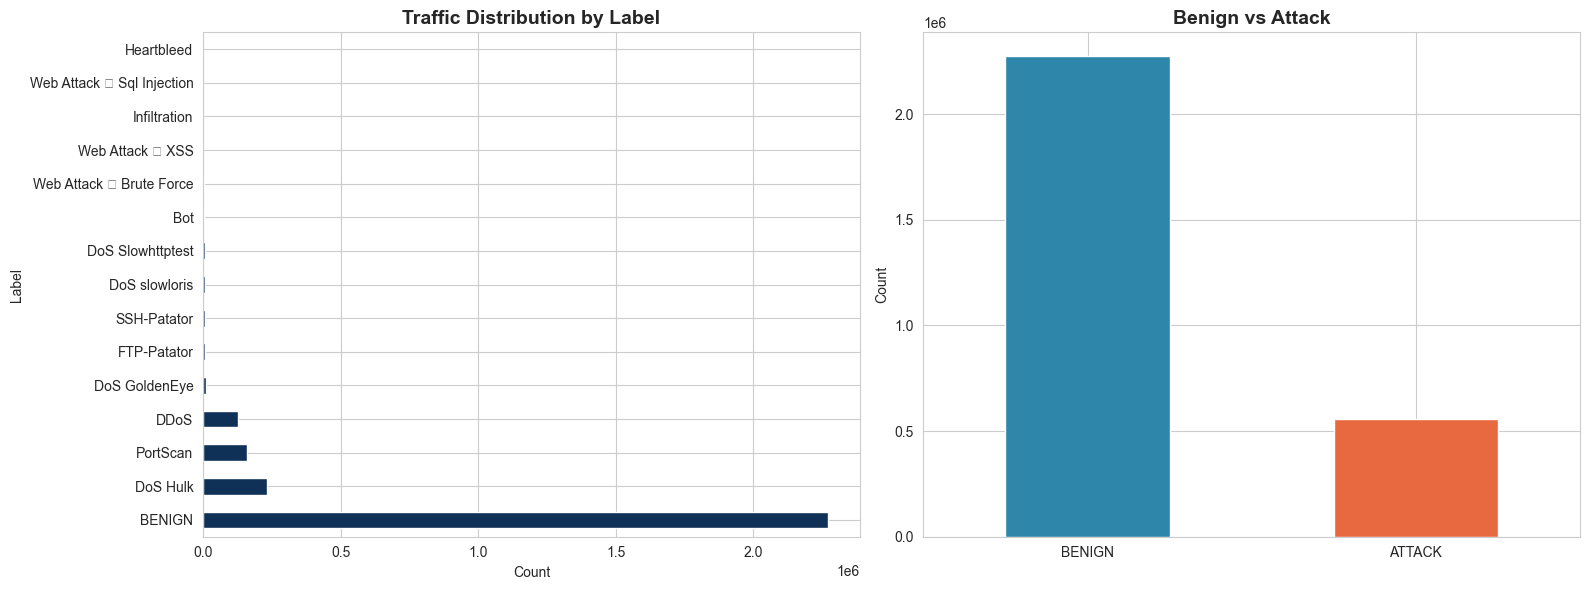

In [ ]:
# ═══════════════════════════════════════════════════
# CELL 6 — Visualize Label Distribution
# ═══════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: All labels
label_counts.plot(kind='barh', ax=axes[0], color='#0F3057')
axes[0].set_title("Traffic Distribution by Label", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Count")

# Plot 2: Binary (Benign vs Attack)
binary_counts = pd.Series({
    'BENIGN': label_counts.get('BENIGN', 0),
    'ATTACK': len(df) - label_counts.get('BENIGN', 0)
})
binary_counts.plot(kind='bar', ax=axes[1], color=['#2E86AB', '#E8683F'])
axes[1].set_title("Benign vs Attack", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("../notebooks/label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════
# CELL 7 — Data Quality Check
# ═══════════════════════════════════════════════════
print("=" * 60)
print("DATA QUALITY:")
print("=" * 60)

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing': missing,
    'Percent': missing_pct
})
missing_report = missing_report[missing_report['Missing'] > 0]

if len(missing_report) > 0:
    print("\nColumns with missing values:")
    print(missing_report)
else:
    print("\n✅ No missing values!")

# Infinite values
print(f"\nInfinite values: {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()}")

# Duplicates
print(f"Duplicate rows: {df.duplicated().sum():,}")

DATA QUALITY:

Columns with missing values:
              Missing  Percent
Flow Bytes/s     1358     0.05

Infinite values: 4376
Duplicate rows: 308,381


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 8 — Statistical Summary
# ═══════════════════════════════════════════════════
print("=" * 60)
print("STATISTICAL SUMMARY (first 20 numeric columns):")
print("=" * 60)

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols[:20]].describe().round(2)

STATISTICAL SUMMARY (first 20 numeric columns):


/Users/apple/NetSentinel/venv/lib/python3.14/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/apple/NetSentinel/venv/lib/python3.14/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min
count,2830743.00,2.830743e+06,2830743.00,2830743.00,2830743.00,2.830743e+06,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2.829385e+06,2830743.00,2.830743e+06,2830743.00,2.830743e+06,2.830743e+06
mean,8071.48,1.478566e+07,9.36,10.39,549.30,1.616264e+04,207.60,18.71,58.20,68.91,870.85,41.05,305.95,335.33,inf,inf,1.298449e+06,2919270.92,9.182475e+06,1.623796e+05
std,18283.63,3.365374e+07,749.67,997.39,9993.59,2.263088e+06,717.18,60.34,186.09,281.19,1946.37,68.86,605.26,839.69,NaN,NaN,4.507944e+06,8045869.78,2.445954e+07,2.950282e+06
min,0.00,-1.300000e+01,1.00,0.00,0.00,0.000000e+00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-2.610000e+08,-2000000.00,-1.300000e+01,0.00,-1.300000e+01,-1.400000e+01
25%,53.00,1.550000e+02,2.00,1.00,12.00,0.000000e+00,6.00,0.00,6.00,0.00,0.00,0.00,0.00,0.00,1.193200e+02,3.45,6.367000e+01,0.00,1.230000e+02,3.000000e+00
50%,80.00,3.131600e+04,2.00,2.00,62.00,1.230000e+02,37.00,2.00,34.00,0.00,79.00,0.00,72.00,0.00,4.595550e+03,110.67,1.143884e+04,137.18,3.086500e+04,4.000000e+00
75%,443.00,3.204828e+06,5.00,4.00,187.00,4.820000e+02,81.00,36.00,50.00,26.16,280.00,77.00,181.00,77.94,1.666667e+05,23255.81,3.374266e+05,691266.28,2.440145e+06,6.400000e+01
max,65535.00,1.200000e+08,219759.00,291922.00,12900000.00,6.554530e+08,24820.00,2325.00,5940.86,7125.60,19530.00,2896.00,5800.50,8194.66,inf,inf,1.200000e+08,84800261.57,1.200000e+08,1.200000e+08


/Users/apple/NetSentinel/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2882: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/Users/apple/NetSentinel/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/apple/NetSentinel/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


TOP 20 FEATURES CORRELATED WITH ATTACK:
Bwd Packet Length Std     0.510216
Bwd Packet Length Max     0.492007
Bwd Packet Length Mean    0.484189
Avg Bwd Segment Size      0.484189
Packet Length Std         0.470252
Max Packet Length         0.454054
Packet Length Variance    0.453847
Fwd IAT Std               0.422755
Packet Length Mean        0.414059
Average Packet Size       0.413037
Idle Max                  0.394220
Idle Mean                 0.390470
Flow IAT Max              0.388666
Fwd IAT Max               0.388642
Idle Min                  0.380651
Flow IAT Std              0.336720
Min Packet Length         0.303164
Bwd Packet Length Min     0.281838
Fwd IAT Total             0.215468
Flow Duration             0.213864
dtype: float64


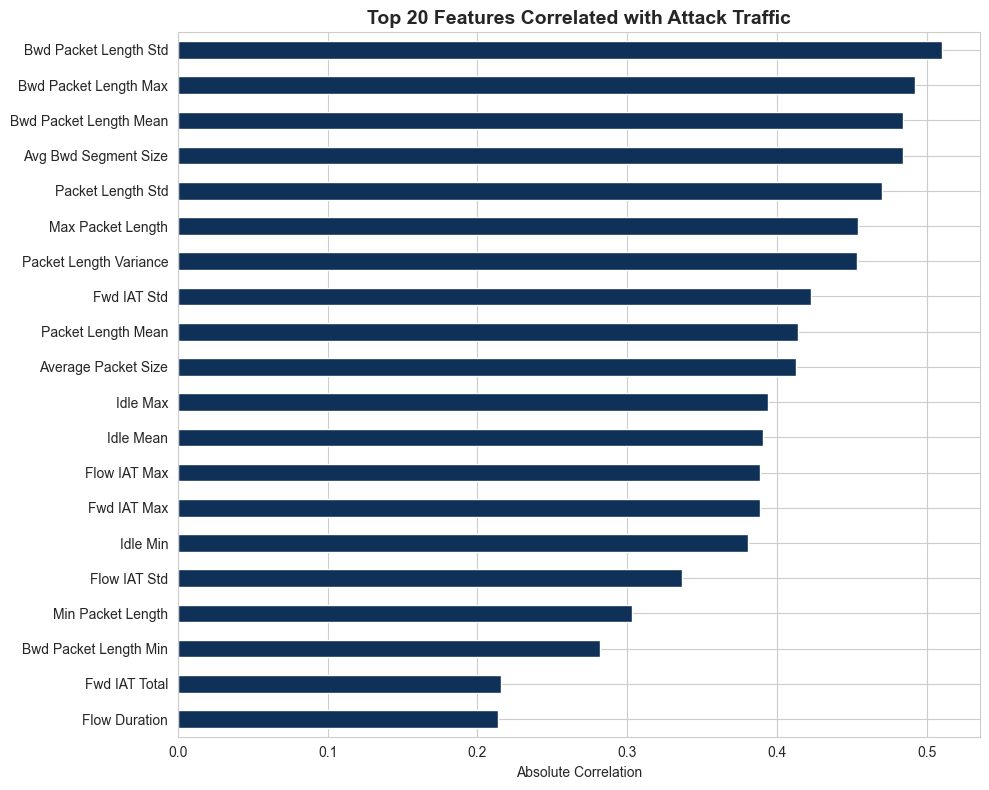

In [ ]:
# ═══════════════════════════════════════════════════
# CELL 9 — Feature Correlation (Top Features)
# ═══════════════════════════════════════════════════

# Create binary label for correlation
df_temp = df.copy()
df_temp['is_attack'] = (df_temp['Label'] != 'BENIGN').astype(int)

# Get correlations with attack label
correlations = df_temp[numeric_cols].corrwith(df_temp['is_attack']).abs().sort_values(ascending=False)

print("=" * 60)
print("TOP 20 FEATURES CORRELATED WITH ATTACK:")
print("=" * 60)
print(correlations.head(20))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
correlations.head(20).plot(kind='barh', ax=ax, color='#0F3057')
ax.set_title("Top 20 Features Correlated with Attack Traffic", fontsize=14, fontweight='bold')
ax.set_xlabel("Absolute Correlation")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../notebooks/feature_correlations.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════
# CELL 10 — Save Exploration Summary
# ═══════════════════════════════════════════════════
summary = {
    'total_samples': len(df),
    'total_features': len(df.columns),
    'numeric_features': len(numeric_cols),
    'label_counts': label_counts.to_dict(),
    'missing_columns': len(missing_report),
    'duplicate_rows': int(df.duplicated().sum()),
    'top_correlated_features': correlations.head(20).index.tolist()
}

import json
with open("../notebooks/exploration_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Exploration complete. Summary saved.")
print(json.dumps(summary, indent=2))

✅ Exploration complete. Summary saved.
{
  "total_samples": 2830743,
  "total_features": 79,
  "numeric_features": 78,
  "label_counts": {
    "BENIGN": 2273097,
    "DoS Hulk": 231073,
    "PortScan": 158930,
    "DDoS": 128027,
    "DoS GoldenEye": 10293,
    "FTP-Patator": 7938,
    "SSH-Patator": 5897,
    "DoS slowloris": 5796,
    "DoS Slowhttptest": 5499,
    "Bot": 1966,
    "Web Attack \ufffd Brute Force": 1507,
    "Web Attack \ufffd XSS": 652,
    "Infiltration": 36,
    "Web Attack \ufffd Sql Injection": 21,
    "Heartbleed": 11
  },
  "missing_columns": 1,
  "duplicate_rows": 308381,
  "top_correlated_features": [
    "Bwd Packet Length Std",
    "Bwd Packet Length Max",
    "Bwd Packet Length Mean",
    "Avg Bwd Segment Size",
    "Packet Length Std",
    "Max Packet Length",
    "Packet Length Variance",
    "Fwd IAT Std",
    "Packet Length Mean",
    "Average Packet Size",
    "Idle Max",
    "Idle Mean",
    "Flow IAT Max",
    "Fwd IAT Max",
    "Idle Min",
    "Flow